# Assignment 4. Deep Learning and Generative models

**Foundations of Data Science**  
*Dr. Khalaj (Fall 2024)*  



In [ ]:
Name = "Rouzbeh Pourjafarian"
Student_id = "400106279"

##  **Part 1 : Transfer Learning**

### 1. 1. Loading Packages


In [ ]:
# Import the required libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import seaborn as sns
from matplotlib.image import imread
from PIL import Image
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from torchvision import transforms, models
from torch.utils.data import DataLoader, Dataset
from torch.optim.lr_scheduler import ReduceLROnPlateau
import warnings
warnings.filterwarnings('ignore')




```
# This is formatted as code
```

### 1. 2. Load and Explore Data

In [ ]:
!wget -O data.zip https://www.dropbox.com/scl/fi/x9wbnxox44rey6xym4un7/data.zip?rlkey=uo2pos87olc6zgkdhp5dcverb&raw=1
!unzip data.zip

Streaming output truncated to the last 5000 lines.
  inflating: chest_xray/train/NORMAL/IM-0435-0001-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0435-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0437-0001-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0437-0001-0002.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0437-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0438-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0439-0001-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0439-0001-0002.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0439-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0440-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0441-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0442-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0444-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0445-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0446-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0447-0001.jpeg  
  inflating:

You will notice that you have three subfolders inside `chest_xray`: train, test, and validation. These will be used for building and evaluating your model's performance. Within each of these folders, you have two subfolders: **NORMAL** and **PNEUMONIA**.

#### 1. 2. 1. The path's variables below point to the negative and positive instances of the training and testing sets (folders). We will use these to check the class distribution in our dataset. In other words, how many positive and negative instances are available. Recall, a hugely imbalanced dataset can lead to biased results.
5 Points

In [ ]:
# Specify the directories for each subfolder
train_NORMAL_dir = 'chest_xray/train/NORMAL'
train_PNEUMONIA_dir = 'chest_xray/train/PNEUMONIA'
test_NORMAL_dir = 'chest_xray/test/NORMAL'
test_PNEUMONIA_dir = 'chest_xray/test/PNEUMONIA'
val_NORMAL_dir = 'chest_xray/val/NORMAL'
val_PNEUMONIA_dir = 'chest_xray/val/PNEUMONIA'

# Calculate the total images in each directory
train_NORMAL_count = sum(1 for _ in os.scandir(train_NORMAL_dir))
train_PNEUMONIA_count = sum(1 for _ in os.scandir(train_PNEUMONIA_dir))
test_NORMAL_count = sum(1 for _ in os.scandir(test_NORMAL_dir))
test_PNEUMONIA_count = sum(1 for _ in os.scandir(test_PNEUMONIA_dir))
val_NORMAL_count = sum(1 for _ in os.scandir(val_NORMAL_dir))
val_PNEUMONIA_count = sum(1 for _ in os.scandir(val_PNEUMONIA_dir))

# Display the results
print(f"Training set includes {train_NORMAL_count} NORMAL and {train_PNEUMONIA_count} PNEUMONIA images.")
print(f"Testing set includes {test_NORMAL_count} NORMAL and {test_PNEUMONIA_count} PNEUMONIA images.")
print(f"Validation set includes {val_NORMAL_count} NORMAL and {val_PNEUMONIA_count} PNEUMONIA images.")


Training set: 1341 NORMAL, 3875 PNEUMONIA
Testing set: 234 NORMAL, 390 PNEUMONIA
Validation set: 8 NORMAL, 8 PNEUMONIA


#### 1. 2. 2. Now create a function to load data to Python.

10 Points

In [ ]:
import os
import numpy as np
from PIL import Image

def load_data(directory):
    img_storage = []  # Store images
    lbl_storage = []  # Store labels

    categories = ['NORMAL', 'PNEUMONIA']  # Define categories
    for category in categories:
        folder_path = os.path.join(directory, category) 
        all_files = os.listdir(folder_path) 
        for single_file in all_files:
            file_path = os.path.join(folder_path, single_file) 
            with Image.open(file_path) as img_object: 
                grayscale_img = img_object.convert('L')  
                resized_img = grayscale_img.resize((150, 150)) 
                img_array = np.array(resized_img)  
            img_storage.append(img_array)  
            lbl_value = 0 if category == 'NORMAL' else 1 
            lbl_storage.append(lbl_value)  

    images = np.array(img_storage)  
    labels = np.array(lbl_storage) 

    return images, labels

# Data directories
train_dir = 'chest_xray/train'
test_dir = 'chest_xray/test'
val_dir = 'chest_xray/val'

# Load data
train_images, train_labels = load_data(train_dir)
test_images, test_labels = load_data(test_dir)
val_images, val_labels = load_data(val_dir)

# Print shapes
print(f'Training data shape: {train_labels.shape}')
print(f'Testing data shape: {test_labels.shape}')
print(f'Validation data shape: {val_labels.shape}')


Training data shape:(5216,)
Testing data shape: (624,)
Validation data shape: (16,)


 #### 1. 2. 3. show the class distributions (0 denotes a normal image, while 1 denotes an image depicting pneumonia) in train and test.
 5 Points

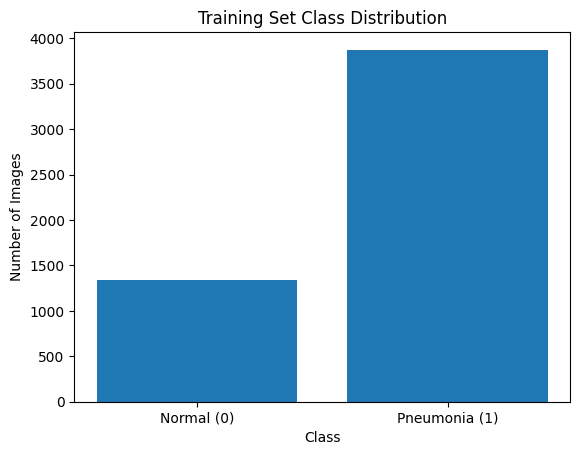

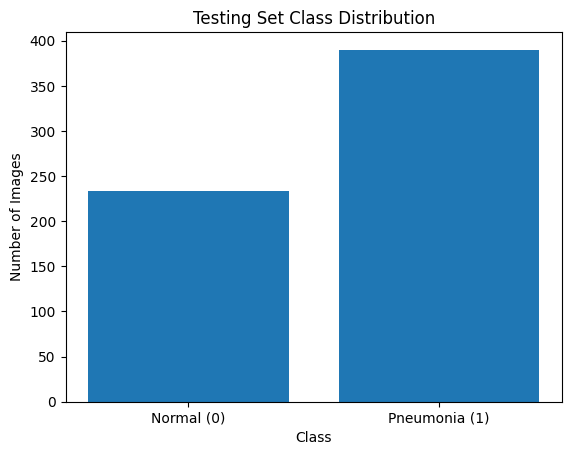

In [ ]:
import matplotlib.pyplot as plt

# Calculate and plot class distributions
def plot_class_distribution(labels, title):
    unique, counts = np.unique(labels, return_counts=True)  # Count unique labels
    plt.bar(unique, counts, tick_label=['Normal (0)', 'Pneumonia (1)'])  # Bar plot
    plt.title(title)  # Set title
    plt.xlabel('Class')  # X-axis label
    plt.ylabel('Number of Images')  # Y-axis label
    plt.show()  # Display the plot

# Plot class distributions for training and testing sets
plot_class_distribution(train_labels, 'Training Set Class Distribution')
plot_class_distribution(test_labels, 'Testing Set Class Distribution')


 #### 1. 2. 4. Write a function to show arbitray number of normal or pneumonia images.
 10 Points

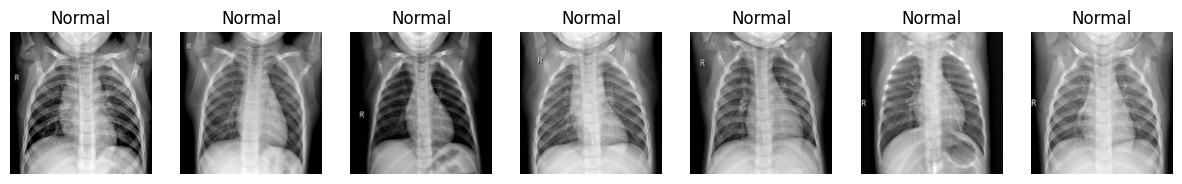

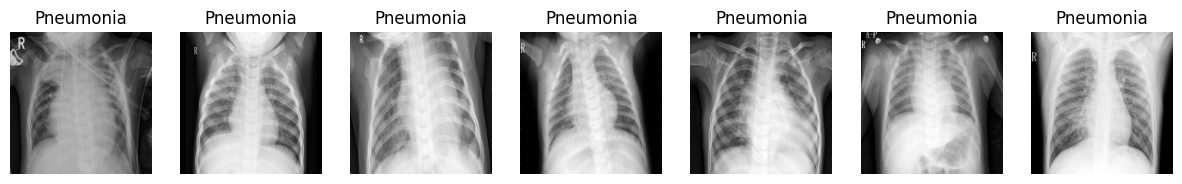

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def show_images(images, labels, label_to_show, num_images=5):
    """
    Display a specified number of random images for a given label (0 for Normal, 1 for Pneumonia).

    Parameters:
        images (numpy array): Array of image data.
        labels (numpy array): Corresponding labels for the images.
        label_to_show (int): Label to filter images (0 for Normal, 1 for Pneumonia).
        num_images (int): Number of images to display. Default is 5.
    """
    # Filter images by the specified label
    filtered_images = images[labels == label_to_show]

    # Randomly select the desired number of images
    selected_indices = np.random.choice(len(filtered_images), num_images, replace=False)
    images_to_display = filtered_images[selected_indices]

    # Create a figure with subplots to display the images
    fig, axes = plt.subplots(1, num_images, figsize=(15, 5))
    for i, image in enumerate(images_to_display):
        axes[i].imshow(image, cmap='gray')  # Display image in grayscale
        axes[i].axis('off')  # Hide axes
        axes[i].set_title('Normal' if label_to_show == 0 else 'Pneumonia')  # Set title

    plt.show()  # Display the figure

# Example usage:
# Display 7 random images of Normal class
show_images(train_images, train_labels, label_to_show=0, num_images=7)

# Display 7 random images of Pneumonia class
show_images(train_images, train_labels, label_to_show=1, num_images=7)


 #### 1. 2. 5. apply histogram equalization to improve images contrast for better visualisation (more about this technique can be found [here](https://homepages.inf.ed.ac.uk/rbf/HIPR2/histeq.htm) and [here](https://scikit-image.org/docs/dev/api/skimage.exposure.html#skimage.exposure.equalize_hist). this gives a better visualisation of the images:
 10 Points

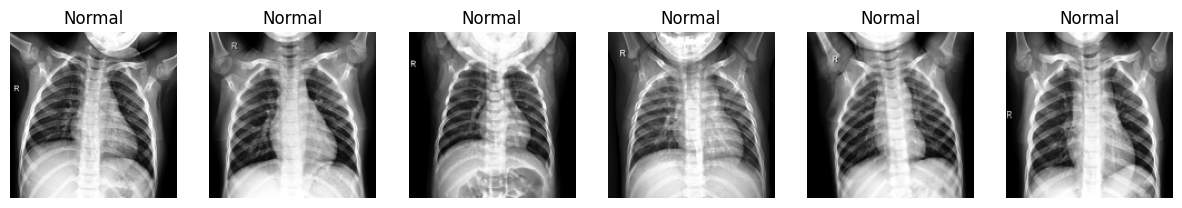

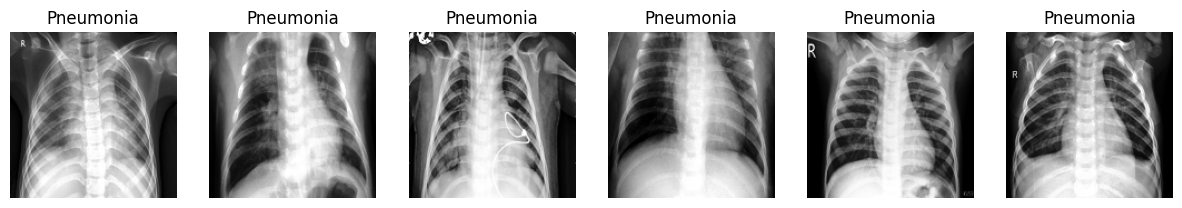

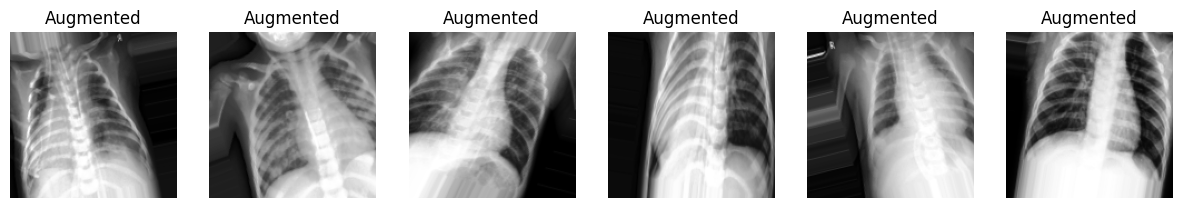

In [ ]:
import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from skimage import exposure
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Load and preprocess the data with histogram equalization
def load_and_equalize_data(directory, img_size=(150, 150)):
    images = []
    labels = []
    class_map = {'NORMAL': 0, 'PNEUMONIA': 1}  # Mapping class names to labels

    for label, class_id in class_map.items():
        class_dir = os.path.join(directory, label)
        for filename in os.listdir(class_dir):
            img_path = os.path.join(class_dir, filename)
            img = Image.open(img_path).convert('L')  # Convert to grayscale
            img = img.resize(img_size)  # Resize to the specified size
            img_array = np.array(img)
            img_eq = exposure.equalize_hist(img_array)  # Apply histogram equalization
            images.append(img_eq)
            labels.append(class_id)

    images = np.array(images, dtype=np.float32)
    labels = np.array(labels, dtype=np.int32)

    # Normalize images to range [0, 1]
    images = (images - images.min()) / (images.max() - images.min())

    # Add channel dimension for CNNs
    images = np.expand_dims(images, axis=-1)

    return images, labels

# Directories for data
train_dir = 'chest_xray/train'
test_dir = 'chest_xray/test'
val_dir = 'chest_xray/val'

# Load and preprocess the data
train_images_eq, train_labels = load_and_equalize_data(train_dir)
test_images_eq, test_labels = load_and_equalize_data(test_dir)
val_images_eq, val_labels = load_and_equalize_data(val_dir)

# Display images for specific classes
def show_images(images, labels, label_to_show, num_images=6):
    """
    Display a set of images for a specific label.

    Parameters:
        images (numpy array): Preprocessed images.
        labels (numpy array): Corresponding labels for the images.
        label_to_show (int): Label to filter images (0 for Normal, 1 for Pneumonia).
        num_images (int): Number of images to display.
    """
    selected_images = images[labels == label_to_show]
    indices = np.random.choice(len(selected_images), num_images, replace=False)
    images_to_show = selected_images[indices]

    # Plot the selected images
    fig, axes = plt.subplots(1, num_images, figsize=(15, 5))
    for i, img in enumerate(images_to_show):
        axes[i].imshow(img.squeeze(), cmap='gray')
        axes[i].axis('off')
        axes[i].set_title('Normal' if label_to_show == 0 else 'Pneumonia')
    plt.show()

# Display random images for each class
show_images(train_images_eq, train_labels, label_to_show=0, num_images=6)
show_images(train_images_eq, train_labels, label_to_show=1, num_images=6)

# Data augmentation
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Fit the generator to the training data
datagen.fit(train_images_eq)

# Create an iterator for augmented data
train_generator = datagen.flow(
    train_images_eq,
    train_labels,
    batch_size=32
)

# Visualize augmented images
def visualize_augmentations(generator, num_images=6):
    """
    Display a set of augmented images from the generator.

    Parameters:
        generator: Data generator for augmented images.
        num_images (int): Number of augmented images to display.
    """
    images, labels = next(generator)  # Get a batch of augmented data
    fig, axes = plt.subplots(1, num_images, figsize=(15, 5))
    for i in range(num_images):
        axes[i].imshow(images[i].squeeze(), cmap='gray')
        axes[i].axis('off')
        axes[i].set_title('Augmented')
    plt.show()

# Display a batch of augmented images
visualize_augmentations(train_generator, num_images=6)


#### 1. 2.6 Use ImageDataGenerator to augment image data by applying random transformations. This is often used in deep learning pipelines to artificially expand the size of the training dataset and improve the model's generalization.

### 2. 1. Build a Vanilla CNN Model


First step, arrange the data in different constructs (x_train, y_train, x_test, y_test, x_val,y_val), etc...):

5 Points

In [ ]:
import numpy as np

# Reshape the image data to include a channel dimension (grayscale images)
x_train = train_images_eq.reshape(-1, 150, 150, 1)
x_test = test_images_eq.reshape(-1, 150, 150, 1)
x_val = val_images_eq.reshape(-1, 150, 150, 1)

# Retain the labels as they are
y_train = train_labels
y_test = test_labels
y_val = val_labels

# Normalize the pixel values to the range [0, 1]
x_train = x_train / 255.0
x_test = x_test / 255.0
x_val = x_val / 255.0

# Print the shapes of the data arrays
print(f"x_train shape: {x_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"x_test shape: {x_test.shape}")
print(f"y_test shape: {y_test.shape}")
print(f"x_val shape: {x_val.shape}")
print(f"y_val shape: {y_val.shape}")


x_train shape: (5216, 150, 150, 1)
y_train shape: (5216,)
x_test shape: (624, 150, 150, 1)
y_test shape: (624,)
x_val shape: (16, 150, 150, 1)
y_val shape: (16,)


#### 2. 1.1. CNN Model
defines a CNN model with more than 18 layer.

1. Notice the **BatchNormalization** layer that is added to the model. This is often used to speed up the training process and make it more stable. It does so by normalizing the inputs from hidden layers.

2. The **Droput** layer: is used to prevent overfitting of the model. It does this by setting some input units to 0 during the training process (e.g. switching off some neurons in the network).

15 Points

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, BatchNormalization, Dropout

# Define a deep CNN model with more than 18 layers
def build_deep_cnn(input_shape):
    model = Sequential([
        # First Convolutional Block
        Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
        BatchNormalization(),
        MaxPooling2D(pool_size=(2, 2)),
        Dropout(rate=0.25),

        # Second Convolutional Block
        Conv2D(64, (3, 3), activation='relu'),
        BatchNormalization(),
        MaxPooling2D(pool_size=(2, 2)),
        Dropout(rate=0.25),

        # Third Convolutional Block
        Conv2D(128, (3, 3), activation='relu'),
        BatchNormalization(),
        MaxPooling2D(pool_size=(2, 2)),
        Dropout(rate=0.25),

        # Fourth Convolutional Block
        Conv2D(256, (3, 3), activation='relu'),
        BatchNormalization(),
        MaxPooling2D(pool_size=(2, 2)),
        Dropout(rate=0.25),

        # Fifth Convolutional Block
        Conv2D(512, (3, 3), activation='relu'),
        BatchNormalization(),
        MaxPooling2D(pool_size=(2, 2)),
        Dropout(rate=0.25),

        # Fully Connected Layers
        Flatten(),
        Dense(512, activation='relu'),
        BatchNormalization(),
        Dropout(rate=0.5),
        Dense(256, activation='relu'),
        BatchNormalization(),
        Dropout(rate=0.5),
        Dense(128, activation='relu'),
        BatchNormalization(),
        Dropout(rate=0.5),
        Dense(1, activation='sigmoid')  # Output for binary classification
    ])
    return model

# Build the model
input_shape = (150, 150, 1)  # Input shape for grayscale images
model = build_deep_cnn(input_shape)

# Compile the model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Display the model's architecture
model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)                    │ (None, 148, 148, 32)        │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_8                │ (None, 148, 148, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 74, 74, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_8 (Dropout)                  │ (None, 74, 74, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_6 (Conv2D)                    │ (None, 72, 72, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_9                │ (None, 72, 72, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_6 (MaxPooling2D)       │ (None, 36, 36, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_9 (Dropout)                  │ (None, 36, 36, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 34, 34, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_10               │ (None, 34, 34, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_7 (MaxPooling2D)       │ (None, 17, 17, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_10 (Dropout)                 │ (None, 17, 17, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_8 (Conv2D)                    │ (None, 15, 15, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_11               │ (None, 15, 15, 256)         │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_8 (MaxPooling2D)       │ (None, 7, 7, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_11 (Dropout)                 │ (None, 7, 7, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_9 (Conv2D)                    │ (None, 5, 5, 512)           │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_12               │ (None, 5, 5, 512)           │           2,048 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_9 (MaxPooling2D)       │ (None, 2, 2, 512)           │              

 Total params: 2,788,993 (10.64 MB)

 Trainable params: 2,785,217 (10.62 MB)

 Non-trainable params: 3,776 (14.75 KB)

#### 2. 1.2. Running The Model

Beafore runing the model use must fix the Imbalance Problem. please write a good solution and apply it to the Data.

10 Points

In [ ]:
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Separate the images and labels by class
normal_images = x_train[y_train == 0]
pneumonia_images = x_train[y_train == 1]
normal_labels = y_train[y_train == 0]
pneumonia_labels = y_train[y_train == 1]

# Calculate class imbalance
normal_count = len(normal_labels)
pneumonia_count = len(pneumonia_labels)
print(f"Normal count: {normal_count}, Pneumonia count: {pneumonia_count}")

# Use ImageDataGenerator to augment the minority class (Normal images)
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Augment the minority class images
num_new_samples = pneumonia_count - normal_count
new_normal_images = []
new_normal_labels = []

for i in range(num_new_samples):
    img = normal_images[i % normal_count].reshape(1, 150, 150, 1)  # Reshape to match expected input
    aug_iter = datagen.flow(img, batch_size=1)  # Generate augmented image
    aug_img = next(aug_iter)[0]  # Retrieve the augmented image
    new_normal_images.append(aug_img)
    new_normal_labels.append(0)  # Label for "Normal" class

# Add the augmented images to the original dataset
balanced_images = np.concatenate((x_train, np.array(new_normal_images)), axis=0)
balanced_labels = np.concatenate((y_train, np.array(new_normal_labels)), axis=0)

# Shuffle the dataset to mix the augmented images with the original ones
shuffle_indices = np.random.permutation(len(balanced_labels))
x_train_balanced = balanced_images[shuffle_indices]
y_train_balanced = balanced_labels[shuffle_indices]

# Display the new class distribution
unique, counts = np.unique(y_train_balanced, return_counts=True)
print(f"Balanced class distribution: {dict(zip(unique, counts))}")


Normal count: 1341, Pneumonia count: 3875
Balanced class distribution: {0: 3875, 1: 3875}


Train the Model on the train data.

10 Points

Epoch 1/20
243/243 ━━━━━━━━━━━━━━━━━━━━ 706s 3s/step - accuracy: 0.7894 - loss: 0.4857 - val_accuracy: 0.5000 - val_loss: 4.2187
Epoch 2/20
243/243 ━━━━━━━━━━━━━━━━━━━━ 706s 3s/step - accuracy: 0.8857 - loss: 0.2715 - val_accuracy: 0.5000 - val_loss: 4.4983
Epoch 3/20
243/243 ━━━━━━━━━━━━━━━━━━━━ 744s 3s/step - accuracy: 0.9208 - loss: 0.1963 - val_accuracy: 0.5000 - val_loss: 4.2606
Epoch 4/20
243/243 ━━━━━━━━━━━━━━━━━━━━ 737s 3s/step - accuracy: 0.9434 - loss: 0.1443 - val_accuracy: 0.5000 - val_loss: 3.8394
Epoch 5/20
243/243 ━━━━━━━━━━━━━━━━━━━━ 733s 3s/step - accuracy: 0.9536 - loss: 0.1291 - val_accuracy: 0.5000 - val_loss: 5.2391
Epoch 6/20
243/243 ━━━━━━━━━━━━━━━━━━━━ 751s 3s/step - accuracy: 0.9562 - loss: 0.1155 - val_accuracy: 0.5000 - val_loss: 61.2117
Epoch 7/20
243/243 ━━━━━━━━━━━━━━━━━━━━ 742s 3s/step - accuracy: 0.9460 - loss: 0.1339 - val_accuracy: 0.5000 - val_loss: 57.2258
Epoch 8/20
243/243 ━━━━━━━━━━━━━━━━━━━━ 743s 3s/step - accuracy: 0.9653 - loss: 0.0954 - val_ac

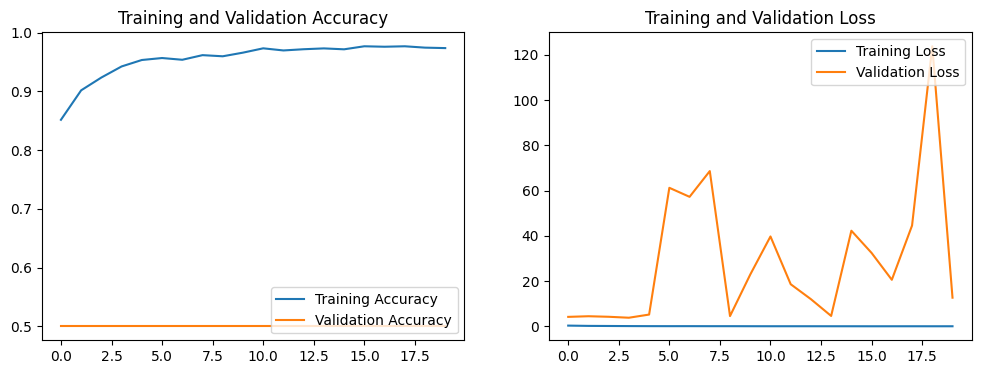

In [ ]:
# Define the number of epochs and batch size
epochs = 20
batch_size = 32

# Train the model
history = model.fit(
    x_train_balanced,
    y_train_balanced,
    epochs=epochs,
    batch_size=batch_size,
    validation_data=(x_val, y_val)
)

# Plot the training history
import matplotlib.pyplot as plt

def plot_training_history(history):
    """
    Plot the training and validation accuracy and loss over epochs.

    Parameters:
        history: History object returned by the model.fit() function.
    """
    acc = history.history['accuracy']  # Training accuracy
    val_acc = history.history['val_accuracy']  # Validation accuracy
    loss = history.history['loss']  # Training loss
    val_loss = history.history['val_loss']  # Validation loss
    epochs_range = range(epochs)  # Range of epochs

    # Set up the figure
    plt.figure(figsize=(12, 4))

    # Plot Training and Validation Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy', marker='o')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy', marker='o')
    plt.legend(loc='lower right')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')

    # Plot Training and Validation Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss', marker='o')
    plt.plot(epochs_range, val_loss, label='Validation Loss', marker='o')
    plt.legend(loc='upper right')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')

    plt.tight_layout()
    plt.show()

# Display the training history
plot_training_history(history)


show and plot the loss curve for training and validation.

10 Points

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Make predictions on the test set
y_pred = model.predict(test_generator)  # Predict probabilities
y_pred = (y_pred > 0.5).astype(int)  # Convert probabilities to binary class labels

# Get true labels from the test generator
y_true = test_generator.classes

# Compute the confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Display the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Pneumonia'])
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()


evaluate the model on test data.

5 Points

### 3.1. Transfer Learning


#### 3.1.1. Pre-trained models

Here, we will use a pre-trained model to perform classification (Transfer Learning). Various models such as VGG16, XCeption,ResNet152V2, etc... can be used.Use one of this models.

Also notice that these models have been trained using large number of images.

30 Points

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ xception (Functional)                │ (None, 4, 4, 2048)          │      20,861,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_5 (Flatten)                  │ (None, 32768)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_18 (Dense)                     │ (None, 512)                 │      16,777,728 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_28               │ (None, 512)                 │           2,048 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_22 (Dropout)                 │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_19 (Dense)                     │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_29               │ (None, 256)                 │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_23 (Dropout)                 │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_20 (Dense)                     │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_30               │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_24 (Dropout)                 │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_21 (Dense)                     │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 37,807,145 (144.22 MB)

 Trainable params: 22,440,193 (85.60 MB)

 Non-trainable params: 15,366,952 (58.62 MB)

Epoch 1/20
326/326 ━━━━━━━━━━━━━━━━━━━━ 671s 2s/step - accuracy: 0.6422 - loss: 0.7863 - val_accuracy: 0.9375 - val_loss: 0.3573
Epoch 2/20
326/326 ━━━━━━━━━━━━━━━━━━━━ 692s 2s/step - accuracy: 0.8295 - loss: 0.4699 - val_accuracy: 0.8750 - val_loss: 0.3568
Epoch 3/20
326/326 ━━━━━━━━━━━━━━━━━━━━ 664s 2s/step - accuracy: 0.8778 - loss: 0.3822 - val_accuracy: 0.8750 - val_loss: 0.2976
Epoch 4/20
326/326 ━━━━━━━━━━━━━━━━━━━━ 680s 2s/step - accuracy: 0.8889 - loss: 0.3284 - val_accuracy: 0.6875 - val_loss: 0.4538
Epoch 5/20
326/326 ━━━━━━━━━━━━━━━━━━━━ 655s 2s/step - accuracy: 0.9139 - loss: 0.2710 - val_accuracy: 0.8125 - val_loss: 0.4515
Epoch 6/20
326/326 ━━━━━━━━━━━━━━━━━━━━ 647s 2s/step - accuracy: 0.9213 - loss: 0.2629 - val_accuracy: 0.7500 - val_loss: 0.4713
Epoch 7/20
326/326 ━━━━━━━━━━━━━━━━━━━━ 679s 2s/step - accuracy: 0.9261 - loss: 0.2330 - val_accuracy: 0.8125 - val_loss: 0.3534
Epoch 8/20
326/326 ━━━━━━━━━━━━━━━━━━━━ 682s 2s/step - accuracy: 0.9339 - loss: 0.1944 - val_accu

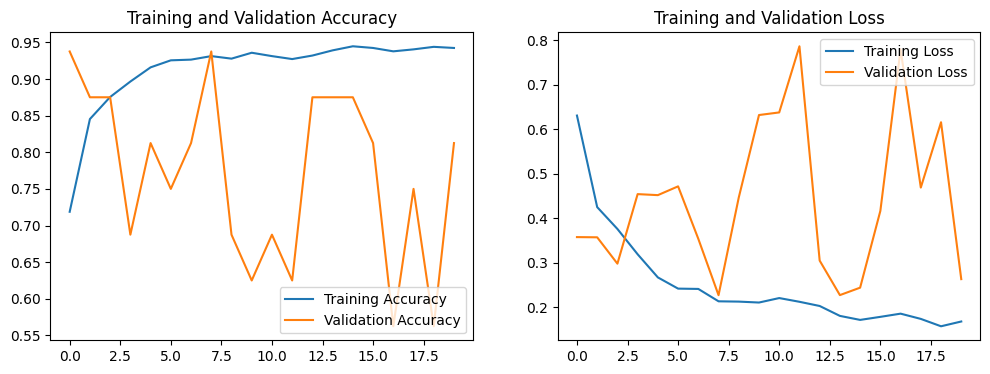

39/39 ━━━━━━━━━━━━━━━━━━━━ 48s 1s/step - accuracy: 0.8996 - loss: 0.2091
Test Loss: 0.19842232763767242
Test Accuracy: 0.9262820482254028
39/39 ━━━━━━━━━━━━━━━━━━━━ 51s 1s/step


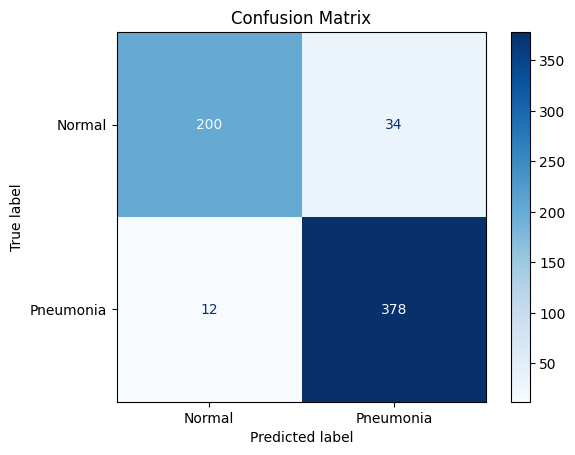

In [ ]:
import os
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import Xception
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import tensorflow as tf

# Define directories
train_dir = 'chest_xray/train'
test_dir = 'chest_xray/test'
val_dir = 'chest_xray/val'

# Data Augmentation and Rescaling for Generators
train_datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    rescale=1./255
)

validation_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

# Data Generators
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(128, 128),  # Resize to 128x128
    batch_size=16,
    class_mode='binary',
    color_mode='rgb'
)

validation_generator = validation_datagen.flow_from_directory(
    val_dir,
    target_size=(128, 128),
    batch_size=16,
    class_mode='binary',
    color_mode='rgb'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(128, 128),
    batch_size=16,
    class_mode='binary',
    color_mode='rgb',
    shuffle=False  # Maintain order for evaluation
)

# Load the Xception model without the top layer
xception_base = Xception(weights='imagenet', include_top=False, input_shape=(128, 128, 3))

# Freeze all but the top layers
for layer in xception_base.layers[:-10]:
    layer.trainable = False

# Build the model on top of Xception
model = Sequential([
    xception_base,
    Flatten(),
    Dense(512, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(1, activation='sigmoid')  # Output layer for binary classification
])

# Compile the model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Display model architecture
model.summary()

# Train the model
epochs = 20
history = model.fit(
    train_generator,
    epochs=epochs,
    validation_data=validation_generator
)

# Plot training history
def plot_training_history(history):
    """
    Plot the training and validation accuracy and loss.

    Parameters:
        history: Training history object.
    """
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(12, 4))

    # Plot Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.legend(loc='lower right')
    plt.title('Training and Validation Accuracy')

    # Plot Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.legend(loc='upper right')
    plt.title('Training and Validation Loss')

    plt.tight_layout()
    plt.show()

plot_training_history(history)

# Evaluate the model on test data
test_loss, test_accuracy = model.evaluate(test_generator)
print(f'Test Loss: {test_loss}')
print(f'Test Accuracy: {test_accuracy}')

# Make predictions
y_pred = model.predict(test_generator)
y_pred = (y_pred > 0.5).astype(int)  # Convert probabilities to binary labels

# Get true labels
y_true = test_generator.classes

# Compute and display confusion matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Pneumonia'])
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()


#### 3.1.2. show the confusion matrix for test data.

5 Points

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Make predictions on the test set
y_pred = model.predict(test_generator)  # Predict probabilities
y_pred = (y_pred > 0.5).astype(int)  # Convert probabilities to binary labels

# Retrieve true labels from the test generator
y_true = test_generator.classes

# Compute the confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Pneumonia'])
disp.plot(cmap=plt.cm.Blues)  # Use a blue colormap for better visibility
plt.title('Confusion Matrix')  # Add title
plt.xlabel('Predicted Labels')  # X-axis label
plt.ylabel('True Labels')  # Y-axis label
plt.show()  # Display the plot


NameError: name 'model' is not defined

### 4.1. Fine-tuning models
Notice that when we used pre-trained models, we haven't changed the weights, or retrained any of the Models layers. Simply put, we have updated the input and output of the models, while keeping all layers of the pre-trained models frozen. Although this is useful, in some cases you need to train some of the layers (update the weights of the model), and this is what is called fine-tuning the models. Here, you must going to unfreeze some layers and retrain. Note also, that we often keep lower layers frozen, because these capture generic features that may be shared with most images.

25 Points


Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ xception (Functional)                │ (None, 4, 4, 2048)          │      20,861,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_2 (Flatten)                  │ (None, 32768)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 512)                 │      16,777,728 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_18               │ (None, 512)                 │           2,048 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_19               │ (None, 256)                 │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_7 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_20               │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_8 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 37,807,145 (144.22 MB)

 Trainable params: 22,440,193 (85.60 MB)

 Non-trainable params: 15,366,952 (58.62 MB)

Epoch 1/20
326/326 ━━━━━━━━━━━━━━━━━━━━ 610s 2s/step - accuracy: 0.6517 - loss: 0.7663 - val_accuracy: 0.8750 - val_loss: 0.4345
Epoch 2/20
326/326 ━━━━━━━━━━━━━━━━━━━━ 587s 2s/step - accuracy: 0.8256 - loss: 0.4529 - val_accuracy: 0.8750 - val_loss: 0.3722
Epoch 3/20
326/326 ━━━━━━━━━━━━━━━━━━━━ 588s 2s/step - accuracy: 0.8807 - loss: 0.3433 - val_accuracy: 0.8750 - val_loss: 0.3483
Epoch 4/20
326/326 ━━━━━━━━━━━━━━━━━━━━ 622s 2s/step - accuracy: 0.8992 - loss: 0.3060 - val_accuracy: 0.8125 - val_loss: 0.4955
Epoch 5/20
326/326 ━━━━━━━━━━━━━━━━━━━━ 609s 2s/step - accuracy: 0.9112 - loss: 0.2672 - val_accuracy: 0.8750 - val_loss: 0.3770
Epoch 6/20
326/326 ━━━━━━━━━━━━━━━━━━━━ 588s 2s/step - accuracy: 0.9229 - loss: 0.2422 - val_accuracy: 0.8750 - val_loss: 0.2709
Epoch 7/20
326/326 ━━━━━━━━━━━━━━━━━━━━ 589s 2s/step - accuracy: 0.9273 - loss: 0.2409 - val_accuracy: 0.8750 - val_loss: 0.4282
Epoch 8/20
326/326 ━━━━━━━━━━━━━━━━━━━━ 621s 2s/step - accuracy: 0.9259 - loss: 0.2460 - val_accu

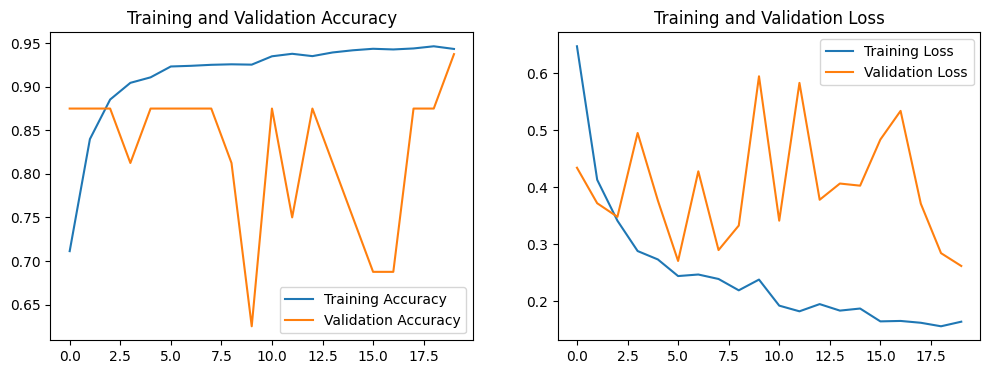

39/39 ━━━━━━━━━━━━━━━━━━━━ 50s 1s/step - accuracy: 0.8343 - loss: 0.4027
Test Loss: 0.289694607257843
Test Accuracy: 0.8910256624221802
39/39 ━━━━━━━━━━━━━━━━━━━━ 50s 1s/step


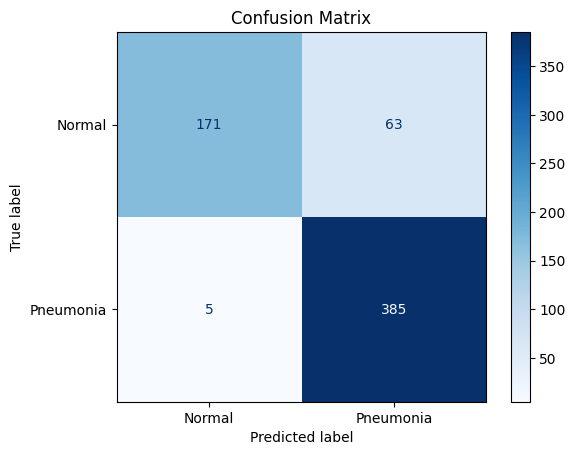

In [15]:
import os
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import Xception
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import tensorflow as tf

# Define data directories
train_path = 'chest_xray/train'
test_path = 'chest_xray/test'
val_path = 'chest_xray/val'

# Create ImageDataGenerator instances for data augmentation and rescaling
train_data_gen = ImageDataGenerator(
    rotation_range=25,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.15,
    zoom_range=0.15,
    horizontal_flip=True,
    fill_mode='nearest',
    rescale=1./255
)

val_data_gen = ImageDataGenerator(rescale=1./255)
test_data_gen = ImageDataGenerator(rescale=1./255)

# Load images using data generators
train_loader = train_data_gen.flow_from_directory(
    train_path,
    target_size=(128, 128),
    batch_size=16,
    class_mode='binary',
    color_mode='rgb'
)

val_loader = val_data_gen.flow_from_directory(
    val_path,
    target_size=(128, 128),
    batch_size=16,
    class_mode='binary',
    color_mode='rgb'
)

test_loader = test_data_gen.flow_from_directory(
    test_path,
    target_size=(128, 128),
    batch_size=16,
    class_mode='binary',
    color_mode='rgb',
    shuffle=False  # Ensure test data remains in order
)

# Load the pre-trained Xception model without its top layer
base_model = Xception(weights='imagenet', include_top=False, input_shape=(128, 128, 3))

# Freeze all layers except for the top layers
for layer in base_model.layers[:-12]:
    layer.trainable = False

# Build the model by adding new layers on top of Xception
model = Sequential([
    base_model,
    Flatten(),
    Dense(512, activation='relu'),
    BatchNormalization(),
    Dropout(0.4),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.4),
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.4),
    Dense(1, activation='sigmoid')  # Output layer for binary classification
])

# Compile the model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Display model architecture
model.summary()

# Train the model
num_epochs = 20
history = model.fit(
    train_loader,
    epochs=num_epochs,
    validation_data=val_loader
)

# Function to plot training history
def plot_training_results(hist):
    """
    Plot the training and validation accuracy and loss.

    Parameters:
        hist: Training history object.
    """
    train_acc = hist.history['accuracy']
    val_acc = hist.history['val_accuracy']
    train_loss = hist.history['loss']
    val_loss = hist.history['val_loss']
    epoch_range = range(len(train_acc))

    plt.figure(figsize=(14, 5))

    # Plot accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epoch_range, train_acc, label='Train Accuracy')
    plt.plot(epoch_range, val_acc, label='Validation Accuracy')
    plt.legend(loc='lower right')
    plt.title('Accuracy')

    # Plot loss
    plt.subplot(1, 2, 2)
    plt.plot(epoch_range, train_loss, label='Train Loss')
    plt.plot(epoch_range, val_loss, label='Validation Loss')
    plt.legend(loc='upper right')
    plt.title('Loss')

    plt.tight_layout()
    plt.show()

# Plot training results
plot_training_results(history)

# Evaluate the model on test data
test_loss, test_acc = model.evaluate(test_loader)

print(f'Test Loss: {test_loss:.4f}')
print(f'Test Accuracy: {test_acc:.4f}')

# Make predictions on test data
predictions = model.predict(test_loader)
predictions_binary = (predictions > 0.5).astype(int)

# Extract true labels from the test generator
true_labels = test_loader.classes

# Compute the confusion matrix
conf_matrix = confusion_matrix(true_labels, predictions_binary)

# Display the confusion matrix
cm_display = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=['Normal', 'Pneumonia'])
cm_display.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()


Evaluate the model on test data.

5 Points

In [ ]:
# Evaluate the model on the test data
test_loss, test_accuracy = model.evaluate(test_generator)

# Print evaluation results
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

# Generate predictions on the test set
y_pred = model.predict(test_generator)  # Predict probabilities
y_pred = (y_pred > 0.5).astype(int)  # Convert probabilities to binary labels (0 or 1)

# Retrieve true labels from the test generator
y_true = test_generator.classes

# Compute the confusion matrix
confusion_mat = confusion_matrix(y_true, y_pred)

# Plot and display the confusion matrix
cm_display = ConfusionMatrixDisplay(confusion_matrix=confusion_mat, display_labels=['Normal', 'Pneumonia'])
cm_display.plot(cmap=plt.cm.Blues)  # Use a blue colormap for better visualization
plt.title('Confusion Matrix')  # Add a title to the plot
plt.xlabel('Predicted Labels')  # Label the x-axis
plt.ylabel('True Labels')  # Label the y-axis
plt.show()


##  **Part 2 : Generative models**


In this part, we are interested in making a generative [VQ-VAE](https://arxiv.org/pdf/1711.00937) model using the CIFAR-10 dataset.

### Import libraries

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

import numpy as np

from tqdm import tqdm
from torchvision.utils import save_image, make_grid

import torchvision.transforms as transforms
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt

# and more, if needed

### Load/download the CIFAR-10 dataset

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as transforms
from torchvision.datasets import CIFAR10
from torch.utils.data import DataLoader
from torchvision.utils import make_grid, save_image
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

# Device configuration
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Dataset loading
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))  # Normalize to [-1, 1]
])

trainset = CIFAR10(root="./data", train=True, transform=transform, download=True)
testset = CIFAR10(root="./data", train=False, transform=transform, download=True)

trainloader = DataLoader(trainset, batch_size=128, shuffle=True)
testloader = DataLoader(testset, batch_size=128, shuffle=False)


Files already downloaded and verified
Files already downloaded and verified


### Define the VQ-VAE model

#### Encoder

You may refer to the paper to mimic their architecture. Nonetheless, here is what the you are meant to implement:

1. **Initialize Convolutional Layers**:
   - **Strided Convolutional Layers**:
     - Create the first strided convolutional layer (`self.strided_conv_1`) to down-sample the input images. This layer should have `input_dim` input channels, `hidden_dim` output channels, and a kernel size of `kernel_1` (e.g., 4). Use a stride of 2 and set the padding to 1.
     - Create the second strided convolutional layer (`self.strided_conv_2`) to further down-sample the images. This layer should have `hidden_dim` input and output channels, and a kernel size of `kernel_2` (e.g., 4). Use a stride of 2 and set the padding to 1.
   
   - **Residual Convolutional Layers**:
     - Create the first residual convolutional layer (`self.residual_conv_1`) to maintain the feature map size. This layer should have `hidden_dim` input and output channels, and a kernel size of `kernel_3` (e.g., 3). Set the padding to 1.
     - Create the second residual convolutional layer (`self.residual_conv_2`) for further processing. This layer should have `hidden_dim` input and output channels, and a kernel size of `kernel_4` (e.g., 1). Set the padding to 0.
   
   - **Projection Layer**:
     - Create a projection layer (`self.proj`) to map the hidden features to the desired output dimensions. This layer should have `hidden_dim` input channels and `output_dim` output channels, and a kernel size of 1.

2. **Implement the Forward Pass**:
   - **Apply Strided Convolutions**:
     - Pass the input tensor `x` through the first strided convolutional layer (`self.strided_conv_1`).
     - Pass the resulting tensor through the second strided convolutional layer (`self.strided_conv_2`).
   
   - **Apply Activation Function**:
     - Apply an activation function to the tensor obtained from the strided convolutions. ReLU is a fine choice.
   
   - **Apply Residual Convolutions**:
     - Pass the activated tensor through the first residual convolutional layer (`self.residual_conv_1`).
     - Add the result of the residual convolution to the original activated tensor (`y + x`).
     - Apply the ReLU activation function to this result.
     - Pass the resulting tensor through the second residual convolutional layer (`self.residual_conv_2`).
     - Add the result of the second residual convolution to the tensor from the previous step (`y + x`).
   
   - **Apply Projection**:
     - Pass the final tensor through the projection layer (`self.proj`) to obtain the encoded output.

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class Encoder(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, kernel_size=(4, 4, 3, 1), stride=2):
        """
        Initializes the Encoder with convolutional and residual layers.

        Args:
            input_dim (int): Number of input channels.
            hidden_dim (int): Number of channels in the hidden layers.
            output_dim (int): Number of output channels.
            kernel_size (tuple): Kernel sizes for each convolutional layer.
            stride (int): Stride for the strided convolutional layers.
        """
        super(Encoder, self).__init__()
        kernel_1, kernel_2, kernel_3, kernel_4 = kernel_size

        # Strided convolutional layers for down-sampling
        self.strided_conv_1 = nn.Conv2d(input_dim, hidden_dim, kernel_1, stride=stride, padding=1)
        self.strided_conv_2 = nn.Conv2d(hidden_dim, hidden_dim, kernel_2, stride=stride, padding=1)

        # Residual convolutional layers for feature refinement
        self.residual_conv_1 = nn.Conv2d(hidden_dim, hidden_dim, kernel_3, padding=1)
        self.residual_conv_2 = nn.Conv2d(hidden_dim, hidden_dim, kernel_4, padding=0)

        # Projection layer to reduce dimensionality
        self.proj = nn.Conv2d(hidden_dim, output_dim, kernel_size=1)

    def forward(self, x):
        """
        Defines the forward pass of the encoder.

        Args:
            x (torch.Tensor): Input tensor of shape (batch_size, input_dim, height, width).

        Returns:
            torch.Tensor: Encoded output of shape (batch_size, output_dim, new_height, new_width).
        """
        # Strided convolutional layers
        x = self.strided_conv_1(x)
        x = self.strided_conv_2(x)
        x = F.relu(x)

        # First residual block
        residual = x
        y = self.residual_conv_1(x)
        y = F.relu(y + residual)

        # Second residual block
        residual = y
        y = self.residual_conv_2(y)
        y = F.relu(y + residual)

        # Projection layer
        z = self.proj(y)

        return z


#### VQEmbeddingEMA

Implement the `VQEmbeddingEMA` class to perform vector quantization with Exponential Moving Average (EMA) updates for embedding vectors.


1. **Initialization**:
    - Initialize the class with parameters: `n_embeddings`, `embedding_dim`, `commitment_cost`, `decay`, and `epsilon`.
    - Create and initialize the embedding matrix with uniform distribution values.
    - Register buffers for `embedding`, `ema_count`, and `ema_weight`.
    - `embedding` should have dimensions `(n_embeddings, embedding_dim)`.
    - Initialize `ema_count` to zeros with shape `(n_embeddings)`.
    - Clone the `embedding` matrix to create `ema_weight`.

2. **Encoding Function**:
    - Implement the `encode` method to perform the quantization process:
        - Flatten the input tensor `x` to shape `(batch_size * seq_length, embedding_dim)`.
        - Calculate the squared Euclidean distances between `x_flat` and the embedding vectors.
        - Find the indices of the nearest embedding vectors.
        - Use these indices to obtain the quantized tensor.
        - Reshape the quantized tensor to match the input tensor’s shape and return it along with the indices.

3. **Retrieve Random Codebook**:
    - Use the provided random indices to retrieve and return the corresponding quantized embeddings, transposed as required.

4. **Forward Pass**:
    - Implement the `forward` method to compute the forward pass:
        - Flatten the input tensor `x` similarly as in the `encode` method.
        - Calculate distances and find the closest embeddings.
        - One-hot encode the indices and obtain the quantized embeddings.
        - During training:
            - Update `ema_count` using the EMA formula.
            - Normalize `ema_count` and update `ema_weight` with the new encodings.
            - Update the embedding vectors using `ema_weight` and `ema_count`.
        - Compute the codebook and commitment losses using MSE.
        - Combine the quantized and original tensors.
        - Calculate the perplexity to measure the diversity of the encodings.
        - Return the quantized tensor, commitment loss, codebook loss, and perplexity.

In [4]:
class VQEmbeddingEMA(nn.Module):
    def __init__(self, n_embeddings, embedding_dim, commitment_cost=0.25, decay=0.999, epsilon=1e-5):
        super(VQEmbeddingEMA, self).__init__()
        self.commitment_cost = commitment_cost
        self.decay = decay
        self.epsilon = epsilon

        init_bound = 1 / n_embeddings
        embedding = torch.Tensor(n_embeddings, embedding_dim)
        embedding.uniform_(-init_bound, init_bound)
        self.register_buffer("embedding", embedding)
        self.register_buffer("ema_count", torch.zeros(n_embeddings))
        self.register_buffer("ema_weight", self.embedding.clone())

    def encode(self, x):
        M, D = self.embedding.size()
        x_flat = x.detach().reshape(-1, D)

        distances = torch.cdist(x_flat, self.embedding) ** 2
        encoding_indices = torch.argmin(distances, dim=1)

        quantized = F.embedding(encoding_indices, self.embedding)
        quantized = quantized.view_as(x)

        return quantized, encoding_indices

    def forward(self, x):
        M, D = self.embedding.size()
        x_flat = x.detach().reshape(-1, D)

        # Calculate distances and encodings
        distances = torch.cdist(x_flat, self.embedding) ** 2
        encoding_indices = torch.argmin(distances, dim=1)
        encodings = F.one_hot(encoding_indices, M).float()

        # Quantize
        quantized = F.embedding(encoding_indices, self.embedding)
        quantized = quantized.view_as(x)

        if self.training:
            # EMA update
            self.ema_count = self.decay * self.ema_count + (1 - self.decay) * torch.sum(encodings, dim=0)
            n = torch.sum(self.ema_count)
            self.ema_count = (self.ema_count + self.epsilon) / (n + M * self.epsilon) * n

            dw = torch.matmul(encodings.t(), x_flat)
            self.ema_weight = self.decay * self.ema_weight + (1 - self.decay) * dw
            self.embedding = self.ema_weight / self.ema_count.unsqueeze(-1)

        # Loss calculation
        e_latent_loss = F.mse_loss(x, quantized.detach())
        q_latent_loss = F.mse_loss(quantized, x.detach())
        commitment_loss = self.commitment_cost * e_latent_loss

        # Straight-through estimator
        quantized = x + (quantized - x).detach()

        # Calculate perplexity
        avg_probs = torch.mean(encodings, dim=0)
        perplexity = torch.exp(-torch.sum(avg_probs * torch.log(avg_probs + 1e-10)))

        return quantized, commitment_loss, q_latent_loss, perplexity

#### Decoder

This is just like the encoder, but in reverse.

In [5]:

class Decoder(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, kernel_sizes=(1, 3, 2, 2), stride=2):
        """
        Initializes the Decoder with transposed convolutional and residual layers.

        Args:
            input_dim (int): Number of input channels.
            hidden_dim (int): Number of channels in the hidden layers.
            output_dim (int): Number of output channels.
            kernel_sizes (tuple): Kernel sizes for each convolutional layer.
            stride (int): Stride for the transposed convolutional layers.
        """
        super(Decoder, self).__init__()
        kernel_1, kernel_2, kernel_3, kernel_4 = kernel_sizes

        # Projection layer to map latent space to hidden dimensions
        self.proj = nn.Conv2d(input_dim, hidden_dim, kernel_1)

        # Residual convolutional layers for feature refinement
        self.residual_conv_1 = nn.Conv2d(hidden_dim, hidden_dim, kernel_2, padding=1)
        self.residual_conv_2 = nn.Conv2d(hidden_dim, hidden_dim, kernel_2, padding=1)

        # Transposed convolutional layers for up-sampling
        self.strided_convt_1 = nn.ConvTranspose2d(hidden_dim, hidden_dim, kernel_3, stride=stride, padding=0)
        self.strided_convt_2 = nn.ConvTranspose2d(hidden_dim, output_dim, kernel_4, stride=stride, padding=0)

    def forward(self, x):
        """
        Defines the forward pass of the decoder.

        Args:
            x (torch.Tensor): Input tensor of shape (batch_size, input_dim, height, width).

        Returns:
            torch.Tensor: Reconstructed output tensor of shape (batch_size, output_dim, new_height, new_width).
        """
        # Projection layer
        x = self.proj(x)
        x = F.relu(x)

        # First residual block
        residual = x
        y = self.residual_conv_1(x)
        y = F.relu(y + residual)

        # Second residual block
        residual = y
        y = self.residual_conv_2(y)
        y = F.relu(y + residual)

        # Transposed convolutions for up-sampling
        y = self.strided_convt_1(y)
        y = F.relu(y)
        y = self.strided_convt_2(y)

        # Output activation
        return torch.tanh(y)


#### The end-to-end model

This is the model you are meant to train.

In [6]:
class Model(nn.Module):
    def __init__(self, Encoder, Codebook, Decoder):
        super(Model, self).__init__()
        self.encoder = Encoder
        self.codebook = Codebook
        self.decoder = Decoder

    def forward(self, x):
        z = self.encoder(x)
        z_quantized, commitment_loss, codebook_loss, perplexity = self.codebook(z)
        x_hat = self.decoder(z_quantized)

        return x_hat, commitment_loss, codebook_loss, perplexity

In [7]:
# Using a GPU is HIGHLY RECOMMENDED. It takes ~1 hour to train 50 epochs on a T4 GPU!
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

batch_size = 128
img_size = (32, 32) # (width, height)

input_dim = 3
hidden_dim = 512
latent_dim = 16
n_embeddings= 512
output_dim = 3
commitment_beta = 0.25

encoder = Encoder(input_dim=input_dim, hidden_dim=hidden_dim, output_dim=latent_dim)
codebook = VQEmbeddingEMA(n_embeddings=n_embeddings, embedding_dim=latent_dim)
decoder = Decoder(input_dim=latent_dim, hidden_dim=hidden_dim, output_dim=output_dim)

model = Model(Encoder=encoder, Codebook=codebook, Decoder=decoder).to(DEVICE)

### Define loss function (reproduction loss) and optimizer

In [9]:
# Define optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=2e-4)

# Define reconstruction loss criterion
reconstruction_criterion = nn.MSELoss()


### Train your model!

In [10]:
import torch
from tqdm import tqdm

# Learning rate and number of epochs
lr = 2e-4
epochs = 15

# Training loop for one epoch
def train_epoch(model, dataloader, optimizer, device):
    """
    Trains the model for one epoch.

    Args:
        model: The PyTorch model to be trained.
        dataloader: DataLoader providing the training data.
        optimizer: Optimizer for updating model weights.
        device: The device to train on (CPU or GPU).

    Returns:
        tuple: Average loss and perplexity for the epoch.
    """
    model.train()  # Set the model to training mode
    total_loss = 0
    total_perplexity = 0

    for batch in tqdm(dataloader, desc="Training Progress"):
        x, _ = batch  # Get input images (x) and labels (_)
        x = x.to(device)  # Move inputs to the specified device

        optimizer.zero_grad()  # Clear gradients
        x_recon, commit_loss, codebook_loss, perplexity = model(x)  # Forward pass

        # Compute reconstruction loss
        recon_loss = reconstruction_criterion(x_recon, x)

        # Total loss: Reconstruction + commitment + codebook losses
        loss = recon_loss + commit_loss + codebook_loss

        loss.backward()  # Backpropagation
        optimizer.step()  # Update model parameters

        # Accumulate loss and perplexity
        total_loss += loss.item()
        total_perplexity += perplexity.item()

    # Return average loss and perplexity
    return total_loss / len(dataloader), total_perplexity / len(dataloader)


# Train the model for the specified number of epochs
for epoch in range(epochs):
    epoch_loss, epoch_perplexity = train_epoch(model, trainloader, optimizer, DEVICE)
    print(f'Epoch {epoch + 1}/{epochs}, Loss: {epoch_loss:.4f}, Perplexity: {epoch_perplexity:.2f}')


100%|██████████| 391/391 [18:45<00:00,  2.88s/it]


Epoch 1, Loss: 0.1618, Perplexity: 319.92


100%|██████████| 391/391 [18:52<00:00,  2.90s/it]


Epoch 2, Loss: 0.1396, Perplexity: 378.82


100%|██████████| 391/391 [58:34<00:00,  8.99s/it]   


...

Epoch 13, Loss: 0.1179, Perplexity: 404.02


100%|██████████| 391/391 [19:39<00:00,  3.02s/it]


Epoch 14, Loss: 0.1172, Perplexity: 404.17


100%|██████████| 391/391 [20:01<00:00,  3.07s/it]

Epoch 15, Loss: 0.1166, Perplexity: 404.41


### Evaluate your model

Report your `perplexity`, `commit_loss` and `codebook_loss` in the test set.

In [11]:
def evaluate(model, dataloader, device):
    """
    Evaluates the model on a given dataset.

    Args:
        model: The PyTorch model to evaluate.
        dataloader: DataLoader providing the evaluation data.
        device: The device to run the evaluation on (CPU or GPU).

    Returns:
        tuple: Average perplexity, commitment loss, and codebook loss over the dataset.
    """
    model.eval()  # Set the model to evaluation mode
    total_perplexity = 0
    total_commit_loss = 0
    total_codebook_loss = 0

    with torch.no_grad():  # Disable gradient computation
        for batch in dataloader:
            x, _ = batch  # Get input images (x) and ignore labels (_)
            x = x.to(device)  # Move inputs to the specified device

            # Forward pass
            x_recon, commit_loss, codebook_loss, perplexity = model(x)

            # Accumulate metrics
            total_perplexity += perplexity.item()
            total_commit_loss += commit_loss.item()
            total_codebook_loss += codebook_loss.item()

    # Compute averages
    n_batches = len(dataloader)
    avg_perplexity = total_perplexity / n_batches
    avg_commit_loss = total_commit_loss / n_batches
    avg_codebook_loss = total_codebook_loss / n_batches

    return avg_perplexity, avg_commit_loss, avg_codebook_loss


Now, draw some of the test set and their reconstructed counterparts in a grid.

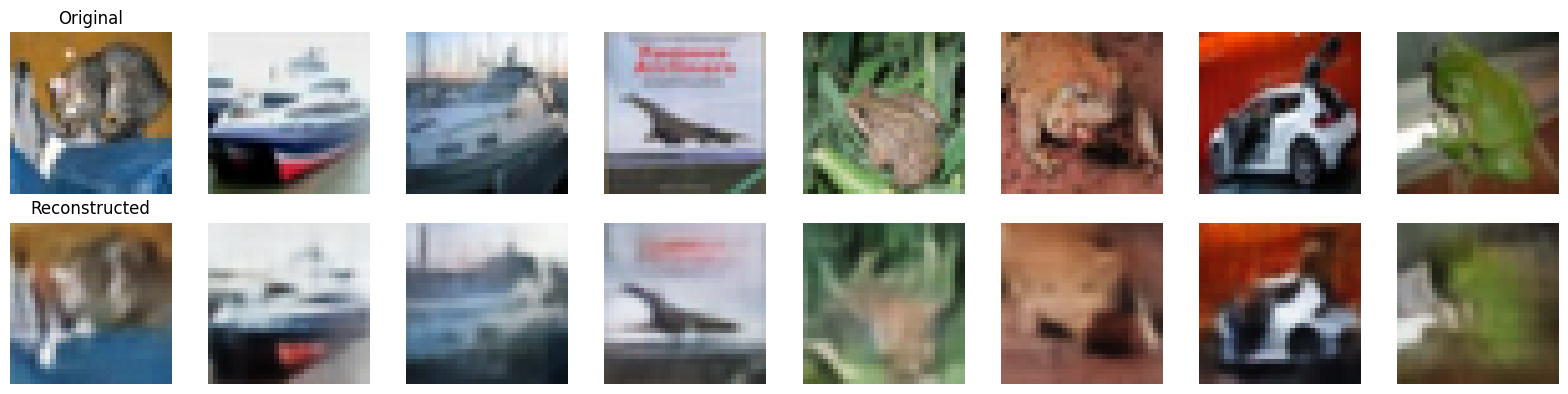

In [12]:
def show_reconstruction_grid(model, dataloader, num_images=8, device='cpu'):
    """
    Displays a grid comparing original and reconstructed images.

    Args:
        model: The trained PyTorch model for reconstruction.
        dataloader: DataLoader providing the dataset.
        num_images: Number of images to display (default: 8).
        device: Device to perform inference ('cpu' or 'cuda').
    """
    model.eval()  # Set the model to evaluation mode

    # Get a batch of images from the dataloader
    test_batch = next(iter(dataloader))
    test_images = test_batch[0][:num_images].to(device)

    with torch.no_grad():  # Disable gradient computation
        # Generate reconstructions from the model
        recons, _, _, _ = model(test_images)

    # Denormalize images (assumes normalization to [-1, 1])
    test_images = test_images * 0.5 + 0.5
    recons = recons * 0.5 + 0.5

    # Create a figure to display images
    fig, axes = plt.subplots(2, num_images, figsize=(2 * num_images, 4))

    for i in range(num_images):
        # Display original images (top row)
        axes[0, i].imshow(test_images[i].cpu().permute(1, 2, 0).clamp(0, 1))  # Clamp to valid range
        axes[0, i].axis('off')  # Turn off axes
        if i == 0:  # Add title to the first image
            axes[0, i].set_title('Original')

        # Display reconstructed images (bottom row)
        axes[1, i].imshow(recons[i].cpu().permute(1, 2, 0).clamp(0, 1))  # Clamp to valid range
        axes[1, i].axis('off')  # Turn off axes
        if i == 0:  # Add title to the first image
            axes[1, i].set_title('Reconstructed')

    plt.tight_layout()  # Adjust layout for better spacing
    plt.show()

# Display reconstructions using the trained model
show_reconstruction_grid(model, testloader, num_images=8, device=DEVICE)


### Generate

Now, generate new pictures. First generate `batch_size//2` random integer indices from 0 to `n_embeddings`, then you may use `retrieve_random_codebook` from your codebook and finally the decoder to generate new images.

In [13]:
def generate_samples(model, n_samples, device):
    """
    Generates new samples using the model's codebook and decoder.

    Args:
        model: The trained PyTorch model (with a codebook and decoder).
        n_samples: Number of samples to generate.
        device: Device for computation ('cpu' or 'cuda').

    Returns:
        torch.Tensor: Generated samples.
    """
    model.eval()  # Set the model to evaluation mode

    with torch.no_grad():  # Disable gradient computation
        # Generate random indices from the codebook
        random_indices = torch.randint(
            0, model.codebook.embedding.size(0),  # Number of embeddings in the codebook
            (n_samples, 8, 8)  # Shape of the latent space (assumes 8x8 grid)
        ).to(device)

        # Retrieve quantized embeddings from the codebook
        quantized = model.codebook.retrieve_random_codebook(random_indices)

        # Decode quantized embeddings into generated samples
        generated = model.decoder(quantized)

    return generated


### optional

The VQ-VAE (Vector Quantized Variational Autoencoder) struggles to produce high-quality generations in some cases due to its reliance on the prior model used to sample the latent space. Specifically, after training the VQ-VAE, the quality of the generated data heavily depends on how well the chosen prior model (e.g., an autoregressive model like PixelCNN) can capture the distribution of the latent space. If the autoregressive model doesn't fully learn the latent distribution, it can result in suboptimal generations, as the latent representations fed into the decoder won't align well with meaningful or realistic patterns.

Your task is to propose a solution and implement it to achieve better results in generation.


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from tqdm import tqdm
import matplotlib.pyplot as plt

# VQEmbeddingEMA Class
class VQEmbeddingEMA(nn.Module):
    def __init__(self, n_embeddings, embedding_dim, commitment_cost=0.25, decay=0.999, epsilon=1e-5):
        super(VQEmbeddingEMA, self).__init__()
        self.commitment_cost = commitment_cost
        self.decay = decay
        self.epsilon = epsilon

        embedding = torch.Tensor(n_embeddings, embedding_dim)
        embedding.uniform_(-1 / n_embeddings, 1 / n_embeddings)
        self.register_buffer("embedding", embedding)
        self.register_buffer("ema_count", torch.zeros(n_embeddings))
        self.register_buffer("ema_weight", self.embedding.clone())

    def encode(self, x):
        x_flat = x.detach().view(-1, self.embedding.size(1))
        distances = torch.cdist(x_flat, self.embedding) ** 2
        encoding_indices = torch.argmin(distances, dim=1)
        quantized = F.embedding(encoding_indices, self.embedding).view_as(x)
        return quantized, encoding_indices

    def forward(self, x):
        x_flat = x.detach().view(-1, self.embedding.size(1))
        distances = torch.cdist(x_flat, self.embedding) ** 2
        encoding_indices = torch.argmin(distances, dim=1)
        encodings = F.one_hot(encoding_indices, self.embedding.size(0)).float()

        quantized = F.embedding(encoding_indices, self.embedding).view_as(x)

        if self.training:
            self.ema_count = self.decay * self.ema_count + (1 - self.decay) * encodings.sum(dim=0)
            dw = torch.matmul(encodings.t(), x_flat)
            self.ema_weight = self.decay * self.ema_weight + (1 - self.decay) * dw
            self.embedding = self.ema_weight / (self.ema_count.unsqueeze(1) + self.epsilon)

        commitment_loss = self.commitment_cost * F.mse_loss(x, quantized.detach())
        quantized = x + (quantized - x).detach()
        return quantized, commitment_l
